<a href="https://colab.research.google.com/github/drskprabhakar/AI-ML-DL-colab-notebooks-coding-models/blob/main/PreopAKrawdata.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
import pandas as pd
import numpy as np


In [41]:
df=pd.read_excel('/content/drive/MyDrive/AK and AR 1wk, 6wk and 3 months.xlsx')

In [42]:
df.head()

,PreopR1,PreopR2,PreopA1,PreopVA,POD 1wkVA,Sph1wk,Cyl1wk,Axis1wk,POD 6wkVA,Sph6wk,Cyl6wk,Axis6wk,POD 3mthVA,Sph3mth,Cyl3mth,Axis3mth
0,46.50,47.25,155,6\24,6\12,0.25,-1.50,115.0,6\12,0.25,-1.25,100.0,6\9,0.5,-1.0,65.0
1,46.75,48.00,80,HM,6\18,0.75,-2.25,80.0,6\18,0.75,-2.00,90.0,6\12,0.5,-2.0,80.0
2,44.00,44.25,20,6\60,6\24,NO CENTER,NaN,NaN,6\24,-1.5,-1.00,140.0,NaN,NaN,NaN,NaN
3,45.25,45.75,120,CF@1M,6\18,-0.75,-1.00,160.0,6\18,-0.5,-0.75,140.0,6\9,-0.5,-0.5,150.0
4,45.50,47.00,80,6\36,6\12,0.25,2.00,75.0,6\12,0.25,2.25,85.0,NaN,NaN,NaN,NaN


In [43]:
sheets= pd.ExcelFile('/content/drive/MyDrive/AK and AR 1wk, 6wk and 3 months.xlsx')
sheets.sheet_names

['data 1wk, 6wk and 3 months', 'raw data']

In [44]:
rawdata = sheets.parse('raw data')

In [45]:
rawdata.head()

,Age,Gender,PreopR1,PreopR2,PreopA1,PreopVA,POD 1wkVA,Sph1wk,Cyl1wk,Axis1wk,POD 6wkVA,Sph6wk,Cyl6wk,Axis6wk,POD 3mthVA,Sph3mth,Cyl3mth,Axis3mth
0,54,F,46.50,47.25,155,6\24,6\12,0.25,-1.50,115.0,6\12,0.25,-1.25,100.0,6\9,0.5,-1.0,65.0
1,63,F,46.75,48.00,80,HM,6\18,0.75,-2.25,80.0,6\18,0.75,-2.00,90.0,6\12,0.5,-2.0,80.0
2,78,F,44.00,44.25,20,6\60,6\24,NO CENTER,NaN,NaN,6\24,-1.5,-1.00,140.0,NaN,NaN,NaN,NaN
3,71,F,45.25,45.75,120,CF@1M,6\18,-0.75,-1.00,160.0,6\18,-0.5,-0.75,140.0,6\9,-0.5,-0.5,150.0
4,89,M,45.50,47.00,80,6\36,6\12,0.25,2.00,75.0,6\12,0.25,2.25,85.0,NaN,NaN,NaN,NaN


In [46]:
rawdata.columns

Index(['Age', 'Gender ', 'PreopR1', 'PreopR2', 'PreopA1', 'PreopVA',
       'POD 1wkVA', 'Sph1wk', 'Cyl1wk', 'Axis1wk', 'POD 6wkVA', 'Sph6wk ',
       'Cyl6wk', 'Axis6wk', 'POD 3mthVA', 'Sph3mth', 'Cyl3mth', 'Axis3mth'],
      dtype='object')

In [47]:
rawdata.shape

(174, 18)

In [48]:
# Function to remove outliers using IQR
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_filtered = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df_filtered

# Columns to remove outliers from
columns_to_filter = ['PreopR1', 'PreopR2', 'PreopA1']

# Apply outlier removal to each specified column
rawdata_filtered = rawdata.copy()
for col in columns_to_filter:
    rawdata_filtered = remove_outliers_iqr(rawdata_filtered, col)

display(rawdata_filtered.head())
display(rawdata_filtered.shape)

,Age,Gender,PreopR1,PreopR2,PreopA1,PreopVA,POD 1wkVA,Sph1wk,Cyl1wk,Axis1wk,POD 6wkVA,Sph6wk,Cyl6wk,Axis6wk,POD 3mthVA,Sph3mth,Cyl3mth,Axis3mth
0,54,F,46.50,47.25,155,6\24,6\12,0.25,-1.50,115.0,6\12,0.25,-1.25,100.0,6\9,0.5,-1.0,65.0
1,63,F,46.75,48.00,80,HM,6\18,0.75,-2.25,80.0,6\18,0.75,-2.00,90.0,6\12,0.5,-2.0,80.0
2,78,F,44.00,44.25,20,6\60,6\24,NO CENTER,NaN,NaN,6\24,-1.5,-1.00,140.0,NaN,NaN,NaN,NaN
3,71,F,45.25,45.75,120,CF@1M,6\18,-0.75,-1.00,160.0,6\18,-0.5,-0.75,140.0,6\9,-0.5,-0.5,150.0
4,89,M,45.50,47.00,80,6\36,6\12,0.25,2.00,75.0,6\12,0.25,2.25,85.0,NaN,NaN,NaN,NaN


(172, 18)

<Axes: >

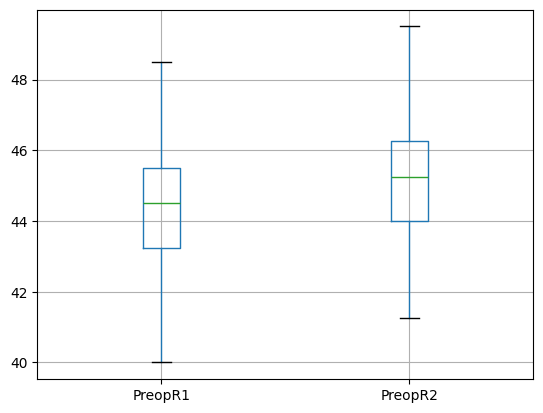

In [49]:
rawdata_filtered.boxplot(column=['PreopR1', 'PreopR2'])




In [50]:
rawdata_filtered.columns

Index(['Age', 'Gender ', 'PreopR1', 'PreopR2', 'PreopA1', 'PreopVA',
       'POD 1wkVA', 'Sph1wk', 'Cyl1wk', 'Axis1wk', 'POD 6wkVA', 'Sph6wk ',
       'Cyl6wk', 'Axis6wk', 'POD 3mthVA', 'Sph3mth', 'Cyl3mth', 'Axis3mth'],
      dtype='object')

In [51]:
import numpy as np
import pandas as pd

def convert_to_logmar(va_string):
    """Converts a visual acuity string (e.g., '6/12', '6\\12', 'HM', 'CF@1M') to logMAR."""
    if isinstance(va_string, str):
        va_string = va_string.strip().upper().replace('\\', '/')

        if '/' in va_string:
            try:
                numerator, denominator = va_string.split('/')
                return np.log10(int(denominator) / int(numerator))
            except ValueError:
                return np.nan

        elif 'NLP' in va_string:
            return 3.0
        elif 'LP' in va_string:
            return 2.3
        elif 'HM' in va_string:
            return 2.9
        elif 'CF' in va_string:
            return 2.6
        elif 'NO CENTER' in va_string:
            return np.nan
        else:
            return np.nan

    elif pd.isna(va_string):
        return np.nan
    else:
        return np.nan


# Apply function
rawdata_filtered['POD 1wkVA LogMAR'] = rawdata_filtered['POD 1wkVA'].apply(convert_to_logmar)
display(rawdata_filtered[['POD 1wkVA', 'POD 1wkVA LogMAR']].head())


,POD 1wkVA,POD 1wkVA LogMAR
0,6\12,0.301030
1,6\18,0.477121
2,6\24,0.602060
3,6\18,0.477121
4,6\12,0.301030


In [52]:
rawdata_filtered

,Age,Gender,PreopR1,PreopR2,PreopA1,PreopVA,POD 1wkVA,Sph1wk,Cyl1wk,Axis1wk,POD 6wkVA,Sph6wk,Cyl6wk,Axis6wk,POD 3mthVA,Sph3mth,Cyl3mth,Axis3mth,POD 1wkVA LogMAR
0,54,F,46.50,47.25,155,6\24,6\12,0.25,-1.50,115.0,6\12,0.25,-1.25,100.0,6\9,0.50,-1.00,65.0,0.301030
1,63,F,46.75,48.00,80,HM,6\18,0.75,-2.25,80.0,6\18,0.75,-2.00,90.0,6\12,0.50,-2.00,80.0,0.477121
2,78,F,44.00,44.25,20,6\60,6\24,NO CENTER,NaN,NaN,6\24,-1.5,-1.00,140.0,NaN,NaN,NaN,NaN,0.602060
3,71,F,45.25,45.75,120,CF@1M,6\18,-0.75,-1.00,160.0,6\18,-0.5,-0.75,140.0,6\9,-0.50,-0.50,150.0,0.477121
4,89,M,45.50,47.00,80,6\36,6\12,0.25,2.00,75.0,6\12,0.25,2.25,85.0,NaN,NaN,NaN,NaN,0.301030
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169,54,M,45.00,46.25,165,6\36,6\18,-2.75,-3.00,75.0,6\12,-2,-2.50,110.0,6\12,-1.75,-2.25,90.0,0.477121
170,57,M,41.00,42.50,85,CF @ 1M,6\18,NO CENTER,NaN,NaN,6\9,-2,-1.25,90.0,6\9,-1.00,-1.25,65.0,0.477121
171,72,M,44.75,45.75,75,6\18,6\36,NO CENTER,NaN,NaN,6\18,-2.5,-4.25,10.0,NaN,NaN,NaN,NaN,0.778151
172,74,M,44.75,45.25,170,6\36,6\18,NO CENTER,NaN,NaN,6\12,-1,3.25,150.0,NaN,NaN,NaN,NaN,0.477121


In [53]:
# Reuse the same function defined earlier
import numpy as np
import pandas as pd

def convert_to_logmar(va_string):
    """Converts a visual acuity string (e.g., '6/12', '6\\12', 'HM', 'CF@1M') to logMAR."""
    if isinstance(va_string, str):
        va_string = va_string.strip().upper().replace('\\', '/')

        if '/' in va_string:
            try:
                numerator, denominator = va_string.split('/')
                return np.log10(int(denominator) / int(numerator))
            except ValueError:
                return np.nan

        elif 'NLP' in va_string:
            return 3.0
        elif 'LP' in va_string:
            return 2.3
        elif 'HM' in va_string:
            return 2.9
        elif 'CF' in va_string:
            return 2.6
        elif 'NO CENTER' in va_string:
            return np.nan
        else:
            return np.nan

    elif pd.isna(va_string):
        return np.nan
    else:
        return np.nan


# ✅ Apply to the 6-week VA column
rawdata_filtered['POD 6wkVA LogMAR'] = rawdata_filtered['POD 6wkVA'].apply(convert_to_logmar)

# ✅ Display a preview
display(rawdata_filtered[['POD 6wkVA', 'POD 6wkVA LogMAR']].head())


,POD 6wkVA,POD 6wkVA LogMAR
0,6\12,0.301030
1,6\18,0.477121
2,6\24,0.602060
3,6\18,0.477121
4,6\12,0.301030


In [54]:
import numpy as np
import pandas as pd

def convert_to_logmar(va_string):
    """Converts a visual acuity string (e.g., '6/12', '6\\12', 'HM', 'CF@1M') to logMAR."""
    if isinstance(va_string, str):
        va_string = va_string.strip().upper().replace('\\', '/')  # handle both \ and /

        if '/' in va_string:
            try:
                numerator, denominator = va_string.split('/')
                return np.log10(int(denominator) / int(numerator))
            except ValueError:
                return np.nan

        elif 'NLP' in va_string:
            return 3.0
        elif 'LP' in va_string:
            return 2.3
        elif 'HM' in va_string:
            return 2.9
        elif 'CF' in va_string:
            return 2.6
        elif 'NO CENTER' in va_string:
            return np.nan
        else:
            return np.nan

    elif pd.isna(va_string):
        return np.nan
    else:
        return np.nan


# ✅ Apply to the 3-month VA column
rawdata_filtered['POD 3mthVA LogMAR'] = rawdata_filtered['POD 3mthVA'].apply(convert_to_logmar)

# ✅ Display a preview
display(rawdata_filtered[['POD 3mthVA', 'POD 3mthVA LogMAR']].head())


,POD 3mthVA,POD 3mthVA LogMAR
0,6\9,0.176091
1,6\12,0.301030
2,NaN,NaN
3,6\9,0.176091
4,NaN,NaN


In [55]:
import numpy as np
import pandas as pd

def convert_to_logmar(va_string):
    """Converts a visual acuity string (e.g., '6/12', '6\\12', 'HM', 'CF@1M') to logMAR."""
    if isinstance(va_string, str):
        va_string = va_string.strip().upper().replace('\\', '/')  # Handle both \ and /

        if '/' in va_string:
            try:
                numerator, denominator = va_string.split('/')
                return np.log10(int(denominator) / int(numerator))
            except ValueError:
                return np.nan

        elif 'NLP' in va_string:
            return 3.0
        elif 'LP' in va_string:
            return 2.3
        elif 'HM' in va_string:
            return 2.9
        elif 'CF' in va_string:
            return 2.6
        elif 'NO CENTER' in va_string:
            return np.nan
        else:
            return np.nan

    elif pd.isna(va_string):
        return np.nan
    else:
        return np.nan


# ✅ Apply to the Preop VA column
rawdata_filtered['PreopVA LogMAR'] = rawdata_filtered['PreopVA'].apply(convert_to_logmar)

# ✅ Display a preview
display(rawdata_filtered[['PreopVA', 'PreopVA LogMAR']].head())


,PreopVA,PreopVA LogMAR
0,6\24,0.602060
1,HM,2.900000
2,6\60,1.000000
3,CF@1M,2.600000
4,6\36,0.778151


In [56]:
rawdata_filtered.to_excel('filtered_data.xlsx', index=False)

In [57]:
rawdata_filtered.shape

(172, 22)

In [58]:
rawdata_filtered.columns

Index(['Age', 'Gender ', 'PreopR1', 'PreopR2', 'PreopA1', 'PreopVA',
       'POD 1wkVA', 'Sph1wk', 'Cyl1wk', 'Axis1wk', 'POD 6wkVA', 'Sph6wk ',
       'Cyl6wk', 'Axis6wk', 'POD 3mthVA', 'Sph3mth', 'Cyl3mth', 'Axis3mth',
       'POD 1wkVA LogMAR', 'POD 6wkVA LogMAR', 'POD 3mthVA LogMAR',
       'PreopVA LogMAR'],
      dtype='object')

In [59]:
# Remove the original VA columns (keep only LogMAR versions)
rawdata_filtered = rawdata_filtered.drop(
    columns=['PreopVA', 'POD 1wkVA', 'POD 6wkVA', 'POD 3mthVA']
)

# Check that the columns were removed
rawdata_filtered.columns


Index(['Age', 'Gender ', 'PreopR1', 'PreopR2', 'PreopA1', 'Sph1wk', 'Cyl1wk',
       'Axis1wk', 'Sph6wk ', 'Cyl6wk', 'Axis6wk', 'Sph3mth', 'Cyl3mth',
       'Axis3mth', 'POD 1wkVA LogMAR', 'POD 6wkVA LogMAR', 'POD 3mthVA LogMAR',
       'PreopVA LogMAR'],
      dtype='object')

In [60]:
rawdata_filtered.head()

,Age,Gender,PreopR1,PreopR2,PreopA1,Sph1wk,Cyl1wk,Axis1wk,Sph6wk,Cyl6wk,Axis6wk,Sph3mth,Cyl3mth,Axis3mth,POD 1wkVA LogMAR,POD 6wkVA LogMAR,POD 3mthVA LogMAR,PreopVA LogMAR
0,54,F,46.50,47.25,155,0.25,-1.50,115.0,0.25,-1.25,100.0,0.5,-1.0,65.0,0.301030,0.301030,0.176091,0.602060
1,63,F,46.75,48.00,80,0.75,-2.25,80.0,0.75,-2.00,90.0,0.5,-2.0,80.0,0.477121,0.477121,0.301030,2.900000
2,78,F,44.00,44.25,20,NO CENTER,NaN,NaN,-1.5,-1.00,140.0,NaN,NaN,NaN,0.602060,0.602060,NaN,1.000000
3,71,F,45.25,45.75,120,-0.75,-1.00,160.0,-0.5,-0.75,140.0,-0.5,-0.5,150.0,0.477121,0.477121,0.176091,2.600000
4,89,M,45.50,47.00,80,0.25,2.00,75.0,0.25,2.25,85.0,NaN,NaN,NaN,0.301030,0.301030,NaN,0.778151


In [61]:
rawdata_filtered.shape

(172, 18)

In [62]:
rawdata_filtered['Age'].describe()

,Age
count,172.000000
mean,63.941860
std,9.826393
min,38.000000
25%,56.750000
50%,65.000000
75%,71.000000
max,93.000000


In [63]:
rawdata_filtered.groupby('Gender ')['Age'].describe()


,count,mean,std,min,25%,50%,75%,max
Gender,,,,,,,,
F,107.0,64.093458,9.737627,39.0,57.0,65.0,71.0,93.0
M,65.0,63.692308,10.041979,38.0,56.0,65.0,69.0,89.0
